##“Social Media Engagement Analytics”

Task 1 — Data Import & Setup

In [1]:
import numpy as np
import pandas as pd

df=pd.read_csv("https://raw.githubusercontent.com/GeethaGunasekaran1/Dataset_rep/main/social_media_engagement_5000.csv")
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


In [3]:
df["posted_at"]=pd.to_datetime(df["posted_at"])

/tmp/ipykernel_182/1507373682.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["posted_at"]=pd.to_datetime(df["posted_at"])


Task 2 — Data Cleaning

 Cleaning Missing Data

In [4]:
df.isnull().sum()

,0
user_id,0
age,150
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,150
comments,150
shares,150


In [5]:
df["age"]=df["age"].fillna(df["age"].mean())
df["likes"]=df["likes"].fillna(df["likes"].median())
df["comments"]=df["comments"].fillna(df["comments"].median())
df["shares"]=df["shares"].fillna(df["shares"].median())

In [6]:
df["gender"]=df["gender"].fillna(df["gender"].mode()[0])
df["sentiment"]=df["sentiment"].fillna(df["sentiment"].mode()[0])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   float64       
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

Duplicate Handling

In [8]:
df.duplicated().sum()


np.int64(0)

Data Formatting

In [9]:
col=["age","likes","comments","shares"]

for c in col:
  df[c]=df[c].astype("int")

In [10]:
categorical_col=df.select_dtypes(include="object").columns
categorical_col

for col in categorical_col:
  print(df[col].value_counts())

gender
Male      1849
Other     1581
Female    1570
Name: count, dtype: int64
country
India        535
Canada       513
Brazil       504
UAE          503
USA          501
France       496
UK           493
Australia    493
Germany      490
Japan        472
Name: count, dtype: int64
post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64
post_category
fitness      675
tech         665
music        635
education    631
lifestyle    607
travel       600
fashion      594
food         593
Name: count, dtype: int64
device_type
mobile     1684
tablet     1658
desktop    1658
Name: count, dtype: int64
sentiment
positive    2513
neutral     1527
negative     960
Name: count, dtype: int64
hashtags
#tech                     201
#love                     176
#fitness                  174
#music                    165
#fun                      163
                         ... 
#fun #foodie #reels         1
#love #tech #music          1
#love #lifestyle #tech      

In [11]:
df[["likes","comments","shares"]].describe()

,likes,comments,shares
count,5000.000000,5000.000000,5000.0000
mean,10106.982400,1502.039800,1002.9106
std,5702.293022,856.393312,570.8552
min,10.000000,0.000000,0.0000
25%,5235.000000,792.000000,511.0000
50%,10105.000000,1497.000000,1012.0000
75%,14959.000000,2235.250000,1483.0000
max,19998.000000,2999.000000,1999.0000


 Feature Cleaning

In [12]:
print(f"hashtags count : {df["hashtags"].count()}")

hashtags count : 5000


In [13]:
print(df["sentiment"].values)

['negative' 'negative' 'positive' ... 'positive' 'positive' 'neutral']


Task 3 — Data Exploration using Pandas

In [14]:
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43,Female,Brazil,496713,image,fitness,7011,354,1157,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33,Male,Brazil,157326,reel,food,11750,2606,1807,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493
2,86820,32,Female,UK,109864,text,food,4862,344,955,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345
3,64886,51,Other,France,848877,text,fitness,5350,1083,1049,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34,Other,UK,449706,image,fitness,12682,2735,1300,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372


In [15]:
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
4995,59500,44,Male,Australia,441541,video,education,16210,2013,1837,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38,Other,UAE,677076,reel,education,16924,2734,1583,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63,Female,USA,273595,text,travel,13487,1497,167,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13,Female,Germany,785644,video,fitness,16894,1289,1713,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518
4999,73400,54,Other,Japan,712252,text,travel,14830,503,1798,3743,14234,2023-03-04,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527


In [16]:
df.shape

(5000, 19)

In [17]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate'],
      dtype='object')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   int64         
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   int64         
 8   comments          5000 non-null   int64         
 9   shares            5000 non-null   int64         
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [19]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10106.982400,1502.039800,1002.9106,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781
50%,54374.500000,38.000000,548077.500000,10105.000000,1497.000000,1012.0000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348
std,26090.370121,14.687151,260646.957267,5702.293022,856.393312,570.8552,2308.096459,28844.939104,NaN,230927.884535,5.318029


In [20]:
df.dtypes

,0
user_id,int64
age,int64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,int64
comments,int64
shares,int64


In [21]:
categorical_col=df.select_dtypes(include="object").columns
categorical_col

for col in categorical_col:
  print(df[col].value_counts())


gender
Male      1849
Other     1581
Female    1570
Name: count, dtype: int64
country
India        535
Canada       513
Brazil       504
UAE          503
USA          501
France       496
UK           493
Australia    493
Germany      490
Japan        472
Name: count, dtype: int64
post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64
post_category
fitness      675
tech         665
music        635
education    631
lifestyle    607
travel       600
fashion      594
food         593
Name: count, dtype: int64
device_type
mobile     1684
tablet     1658
desktop    1658
Name: count, dtype: int64
sentiment
positive    2513
neutral     1527
negative     960
Name: count, dtype: int64
hashtags
#tech                     201
#love                     176
#fitness                  174
#music                    165
#fun                      163
                         ... 
#fun #foodie #reels         1
#love #tech #music          1
#love #lifestyle #tech      

In [22]:
for col in categorical_col:
  print(df[col].unique())

['Female' 'Male' 'Other']
['Brazil' 'UK' 'France' 'Canada' 'Japan' 'Australia' 'India' 'UAE'
 'Germany' 'USA']
['image' 'reel' 'text' 'video']
['fitness' 'food' 'tech' 'travel' 'fashion' 'lifestyle' 'education'
 'music']
['mobile' 'tablet' 'desktop']
['negative' 'positive' 'neutral']
['#foodie #travel #love' '#fitness' '#foodie' '#music #foodie #fun'
 '#travel' '#music' '#travel #music #fitness' '#music #fun #fitness'
 '#lifestyle #love' '#tech' '#fun #fashion #love' '#foodie #lifestyle'
 '#foodie #fashion' '#reels' '#foodie #fun #lifestyle'
 '#love #fashion #fitness' '#foodie #travel #fitness' '#foodie #fitness'
 '#fun' '#reels #fashion' '#fashion' '#fitness #love'
 '#foodie #tech #fitness' '#love #music' '#love #foodie' '#lifestyle'
 '#fashion #fitness #reels' '#reels #tech' '#tech #fitness'
 '#music #lifestyle #love' '#lifestyle #fun #music' '#fitness #tech'
 '#reels #foodie #travel' '#tech #fun #foodie' '#fun #reels'
 '#love #music #travel' '#foodie #music #love' '#fashion #foodie 

In [23]:
for col in categorical_col:
  print(f"{col} : {df[col].nunique()}")

gender : 3
country : 10
post_type : 4
post_category : 8
device_type : 3
sentiment : 3
hashtags : 761


In [24]:
numerical_col=df.select_dtypes(include="number").columns

df[numerical_col].corr()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate
user_id,1.000000,-0.006688,0.020051,0.025811,-0.033395,0.013763,-0.016847,0.015326,0.010124,-0.004282
age,-0.006688,1.000000,-0.013153,-0.036323,-0.007284,0.013871,0.005542,0.013322,-0.024894,0.008039
post_id,0.020051,-0.013153,1.000000,0.014526,-0.010540,0.001846,0.018374,-0.007709,-0.002844,0.010139
likes,0.025811,-0.036323,0.014526,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,0.093521
comments,-0.033395,-0.007284,-0.010540,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,0.000051
shares,0.013763,0.013871,0.001846,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.021724
watch_time_sec,-0.016847,0.005542,0.018374,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,-0.001148
impression_count,0.015326,0.013322,-0.007709,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,-0.232226
follower_count,0.010124,-0.024894,-0.002844,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,0.002292
engagement_rate,-0.004282,0.008039,0.010139,0.093521,0.000051,0.021724,-0.001148,-0.232226,0.002292,1.000000


In [25]:
#avg likes by post type
df.groupby("post_type")["likes"].mean()

,likes
post_type,
image,10104.852446
reel,10037.784879
text,10100.132530
video,10188.586122


In [26]:
# impressions by country
df.groupby("country")["impression_count"].count()

,impression_count
country,
Australia,493
Brazil,504
Canada,513
France,496
Germany,490
India,535
Japan,472
UAE,503
UK,493


In [27]:
#genderwise avg age
df.groupby("gender")["age"].mean().astype(int)

,age
gender,
Female,38
Male,38
Other,38


In [28]:
#Post count by device type
df.groupby("device_type")["post_id"].count()

,post_id
device_type,
desktop,1658
mobile,1684
tablet,1658


In [29]:
#categorywise avg rating
df.groupby("post_category")["engagement_rate"].mean()

,engagement_rate
post_category,
education,0.844222
fashion,0.807109
fitness,0.865628
food,1.358628
lifestyle,1.091019
music,0.888803
tech,1.160475
travel,0.702223


In [30]:
#Post Category vs Average Engagement
df.groupby("post_category").agg({'likes':"mean", 'comments':"mean", 'shares':"mean"}).round(2).reset_index()

,post_category,likes,comments,shares
0,education,10126.47,1455.34,996.45
1,fashion,9843.34,1530.54,982.52
2,fitness,9914.59,1501.14,1042.05
3,food,10225.50,1510.88,1002.80
4,lifestyle,10180.54,1467.84,991.14
5,music,10205.74,1558.71,1024.09
6,tech,10171.56,1505.55,1009.37
7,travel,10196.29,1485.95,968.31


In [31]:
# Count of Users by Country
df.groupby('country')["user_id"].count()

,user_id
country,
Australia,493
Brazil,504
Canada,513
France,496
Germany,490
India,535
Japan,472
UAE,503
UK,493


In [32]:
#Average Post ID by Sentiment
df.groupby("sentiment")["post_id"].mean().astype(int)

,post_id
sentiment,
negative,554990
neutral,537427
positive,551839


Task 4 — Data Wrangling

In [33]:
df1=pd.DataFrame({
                  "user_id":df["user_id"],
                  "engagement_score":df["likes"]+df["comments"]+df["shares"],
                  "hashtage_count":df["hashtags"].str.count("#")
                  })

df1

df=df.merge(df1,on="user_id",how="inner")


In [34]:
df.groupby(["post_type","sentiment"])["hashtage_count"].count().reset_index()

,post_type,sentiment,hashtage_count
0,image,negative,234
1,image,neutral,407
2,image,positive,678
3,reel,negative,270
4,reel,neutral,415
5,reel,positive,685
6,text,negative,244
7,text,neutral,418
8,text,positive,649
9,video,negative,265


In [35]:
df.groupby("country")["engagement_score"].mean().round(2).sort_values(ascending=False)

,engagement_score
country,
France,12899.68
Australia,12865.63
UAE,12774.79
Germany,12668.01
USA,12606.44
Canada,12565.25
India,12516.76
Japan,12488.99
Brazil,12414.00


Task 5 — Statistical Analysis

In [36]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,engagement_score,hashtage_count
count,5282.000000,5282.000000,5282.000000,5282.000000,5282.000000,5282.000000,5282.000000,5282.000000,5282,5282.000000,5282.000000,5282.000000,5282.000000
mean,54365.120788,38.438470,547337.064180,10116.843998,1499.199924,1003.555282,4009.854790,50000.062476,2022-12-29 14:56:23.263915264,394348.571564,0.943087,12619.599205,1.998864
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.000000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,193.000000,1.000000
25%,32069.500000,26.000000,320238.000000,5237.250000,792.000000,512.000000,2029.250000,25004.000000,2022-07-05 00:00:00,195405.000000,0.146601,7823.000000,1.000000
50%,54242.500000,38.000000,547575.500000,10105.000000,1497.000000,1012.000000,4014.000000,49981.000000,2022-12-29 12:00:00,389253.500000,0.254252,12576.000000,2.000000
75%,76775.000000,51.000000,771635.500000,14992.750000,2234.000000,1483.000000,6015.500000,74539.500000,2023-06-28 00:00:00,590507.250000,0.506607,17482.750000,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.000000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,24680.000000,3.000000
std,26015.825797,14.657502,261509.164422,5698.600168,856.081105,571.143504,2301.971518,28792.986995,NaN,230922.719534,5.181496,5779.627673,0.810599


Task 6 — Data Visualization


Matplotlib


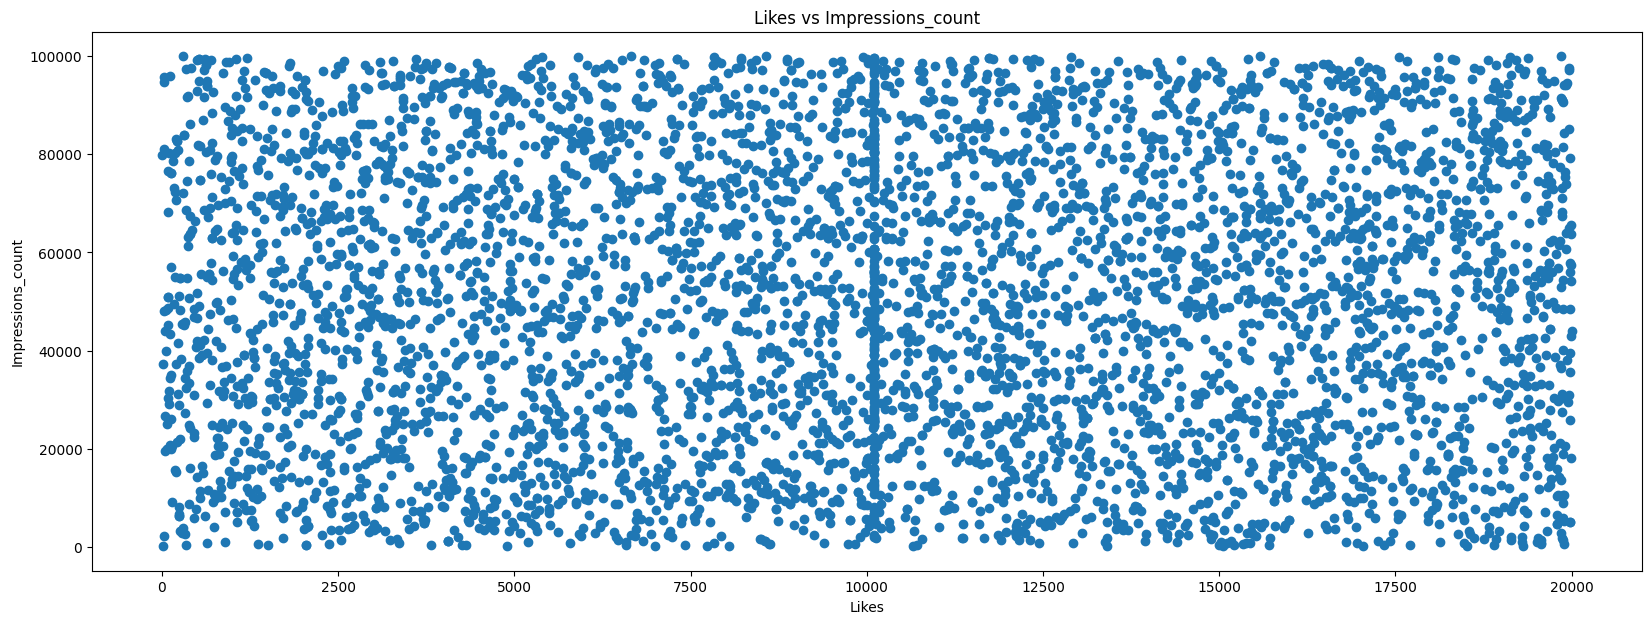

In [37]:
#scatter: likes vs impressions
import matplotlib.pyplot as plt

plt.figure(figsize=(20,7))
plt.scatter(df["likes"],df["impression_count"])
plt.title("Likes vs Impressions_count")
plt.xlabel("Likes")
plt.ylabel("Impressions_count")
plt.show()

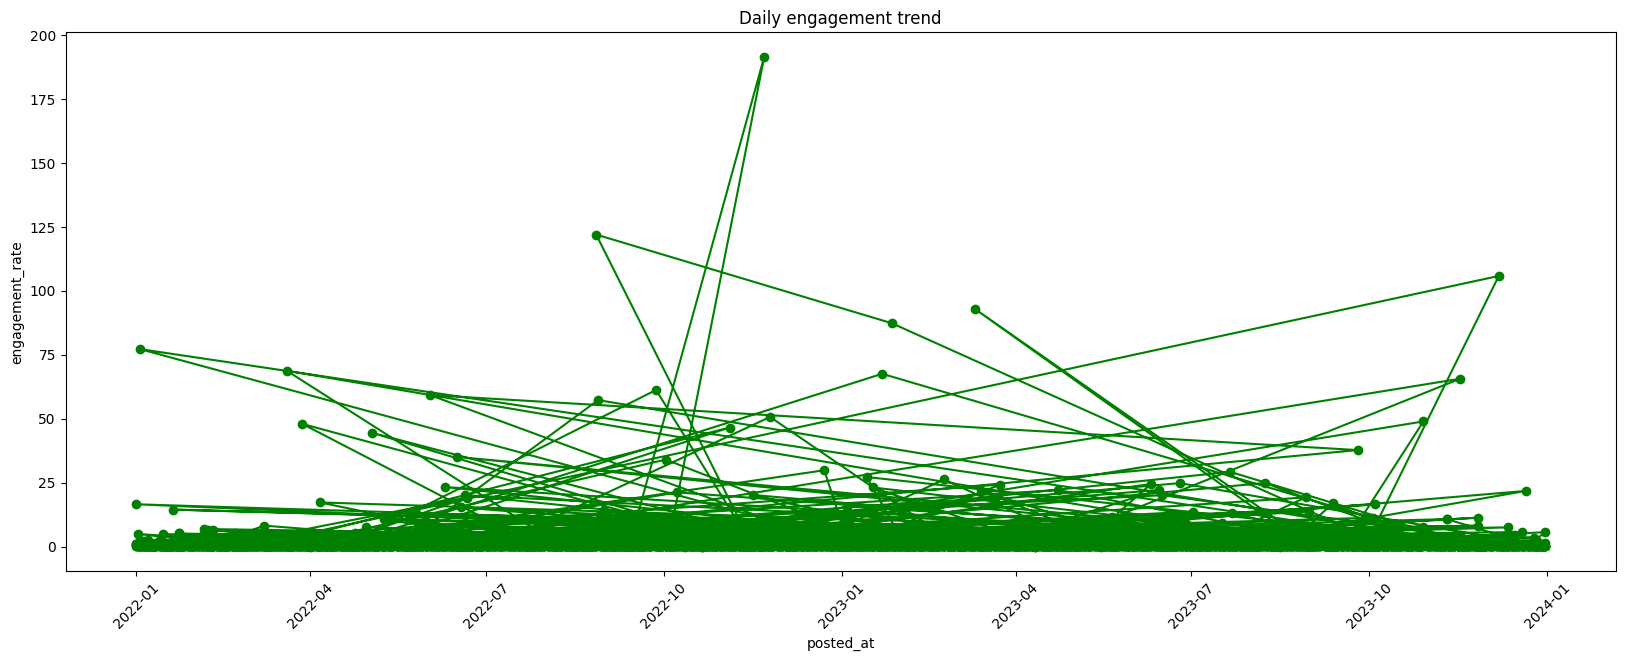

In [38]:
#Line: daily engagement trend

plt.figure(figsize=(20,7))
plt.plot(df["posted_at"],df["engagement_rate"],color="g",marker="o")
plt.title("Daily engagement trend")
plt.xlabel("posted_at")
plt.ylabel("engagement_rate")
plt.xticks(rotation=45)
plt.show()

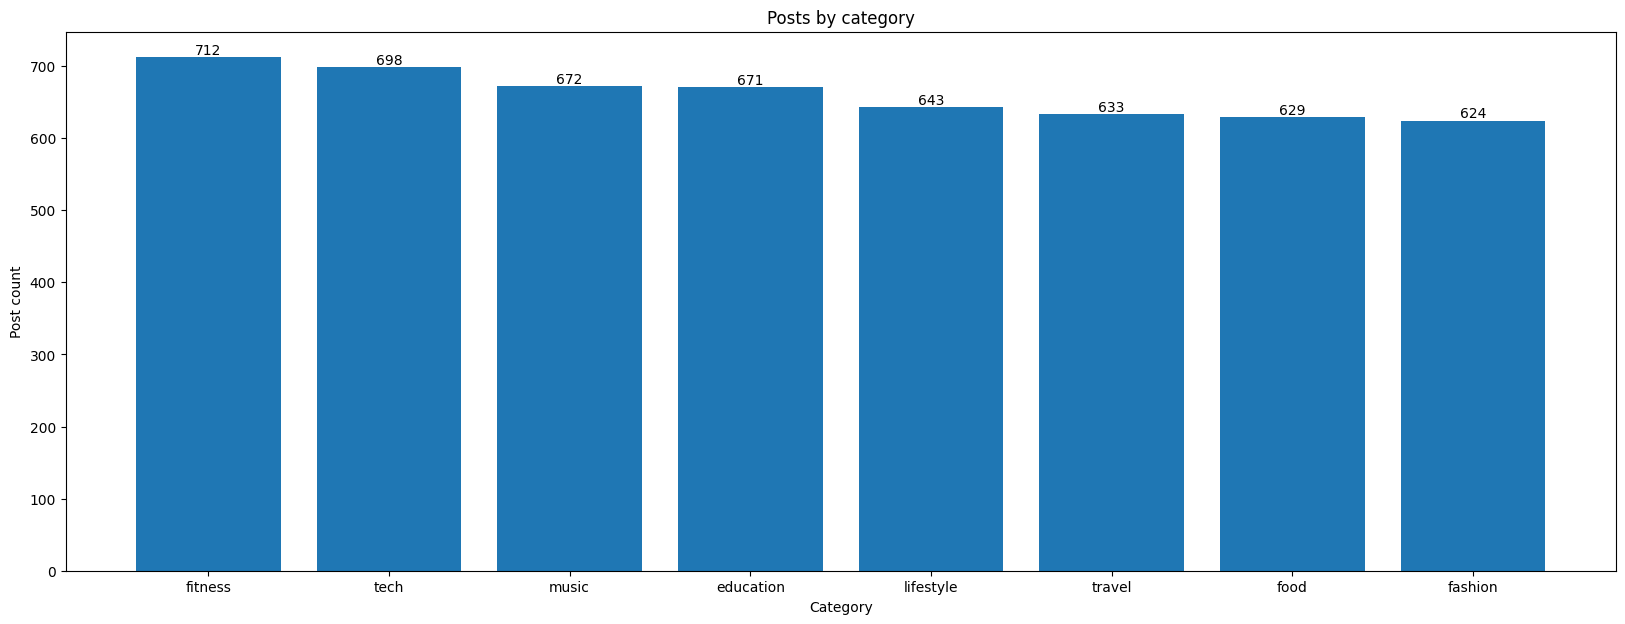

In [39]:
#Bar: posts by category

category_counts = df["post_category"].value_counts()

plt.figure(figsize=(20,7))
ax=plt.bar(category_counts.index,category_counts.values)
plt.bar_label(ax)
plt.title("Posts by category")
plt.xlabel("Category")
plt.ylabel("Post count")
plt.show()

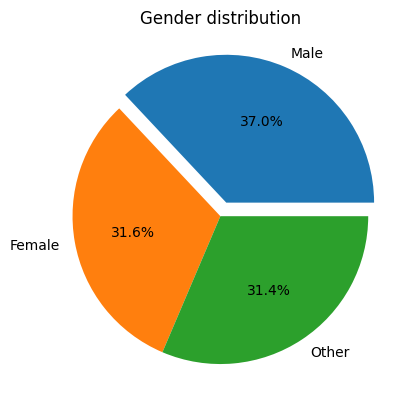

In [40]:
#Pie: gender distribution
gender_count=df["gender"].value_counts()

plt.pie(gender_count,autopct='%0.1f%%',labels=gender_count.index,explode=(0.1,0,0))
plt.title("Gender distribution")
plt.show()

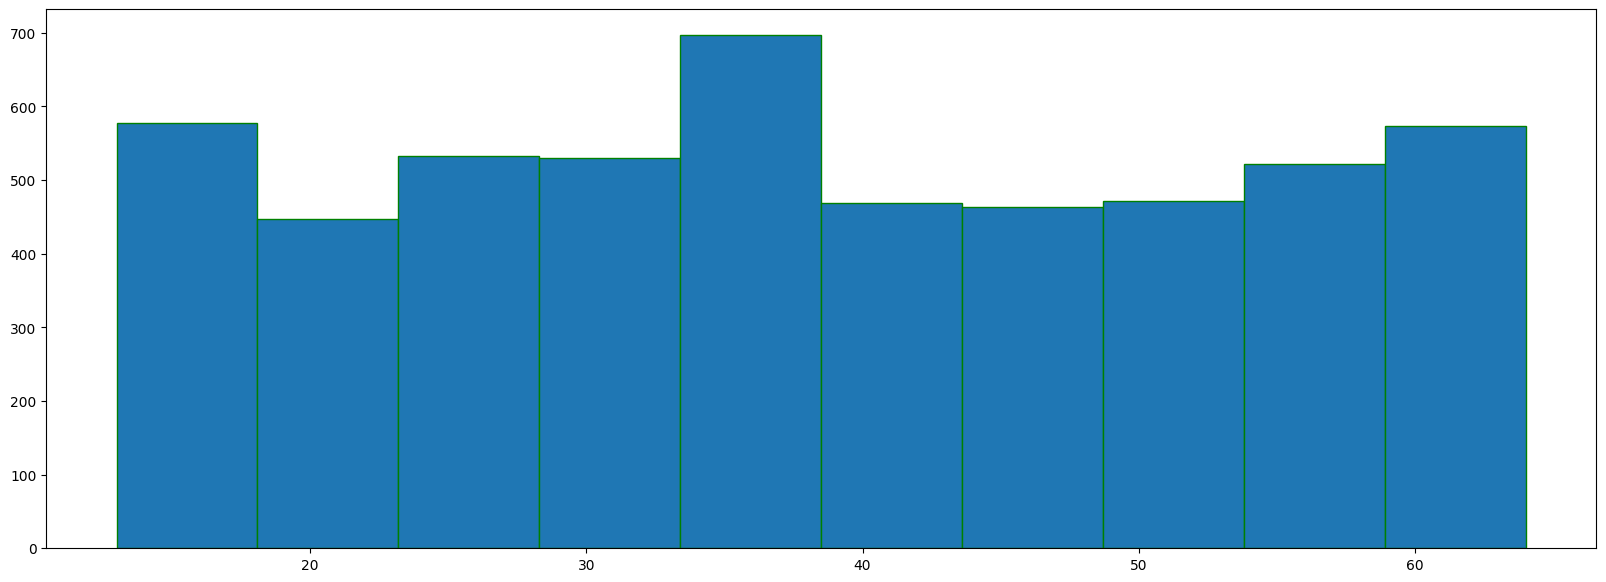

In [41]:
#Histogram: age

plt.figure(figsize=(20,7))
plt.hist(df["age"],bins=10,edgecolor="g")
plt.show()

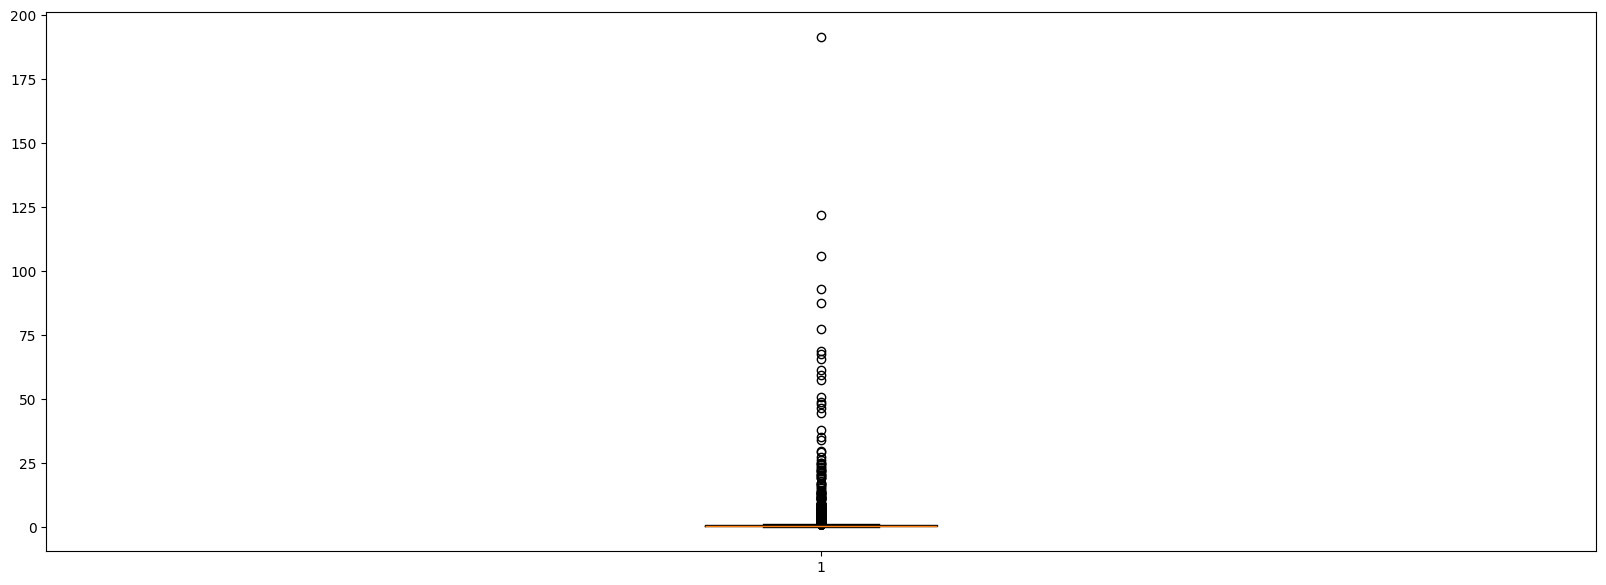

In [42]:
#Box: engagement rate

plt.figure(figsize=(20,7))
plt.boxplot(df["engagement_rate"])
plt.show()

Seaborn

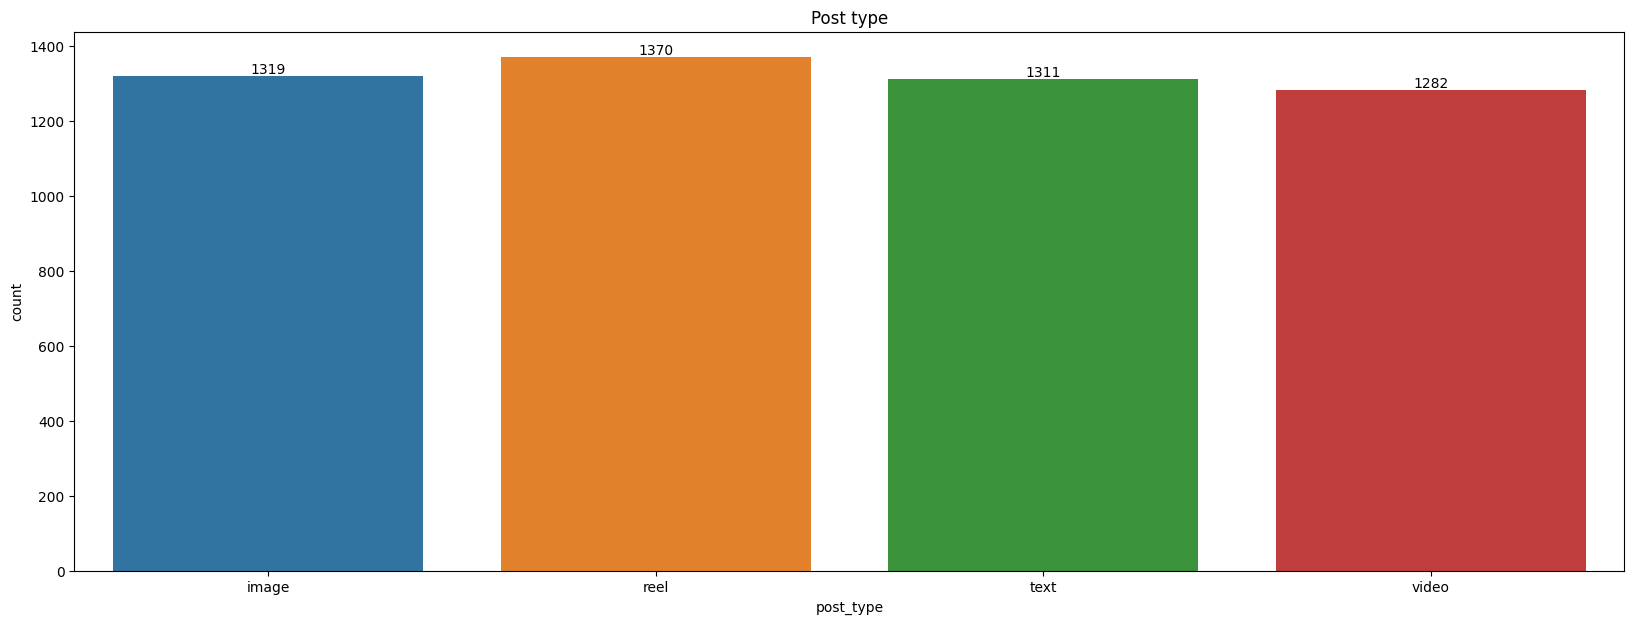

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

#Count plot: post type

plt.figure(figsize=(20,7))
ax1=sns.countplot(data=df,x="post_type",hue="post_type")
for container in ax1.containers:
    ax1.bar_label(container)
plt.title("Post type")
plt.show()

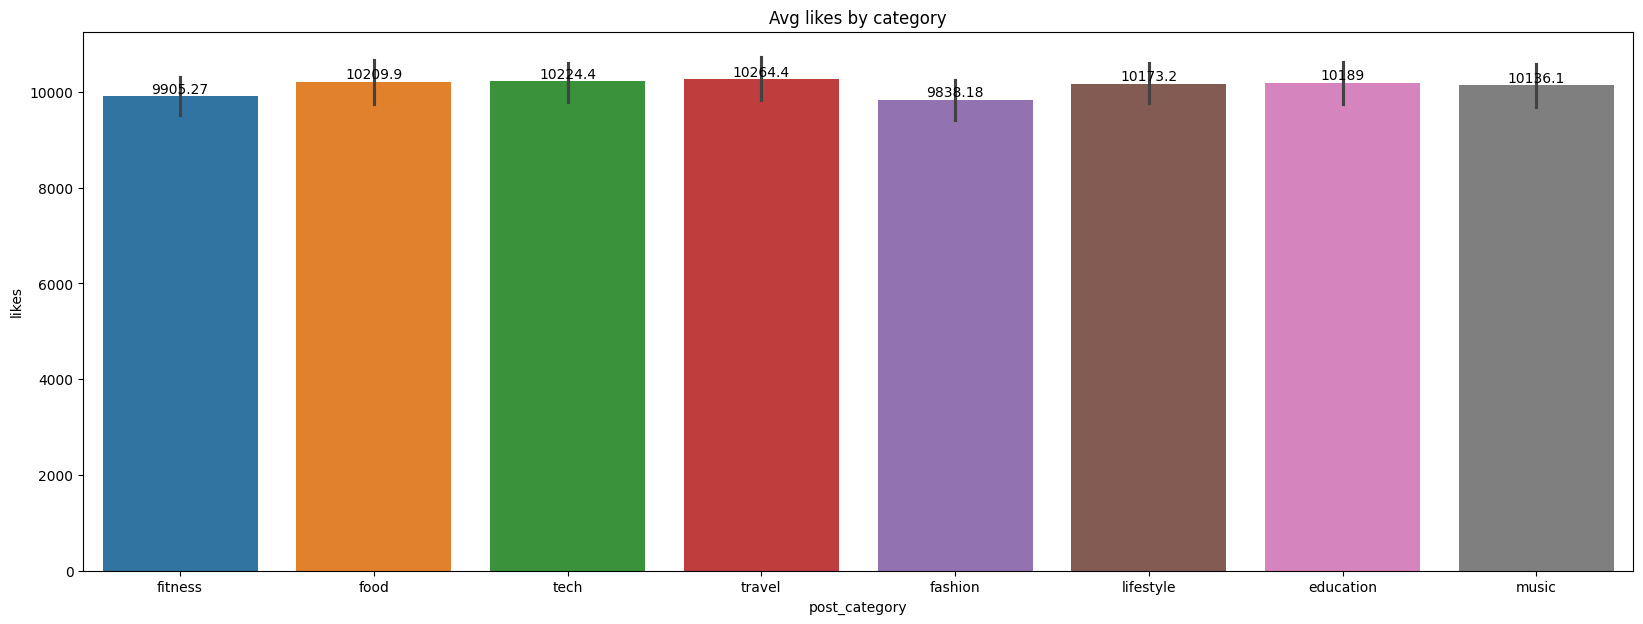

In [44]:
#Bar plot: avg likes by category

plt.figure(figsize=(20,7))
ax2=sns.barplot(data=df,x="post_category",y="likes",hue="post_category")
for container in ax2.containers:
    ax2.bar_label(container)
plt.title("Avg likes by category")
plt.show()

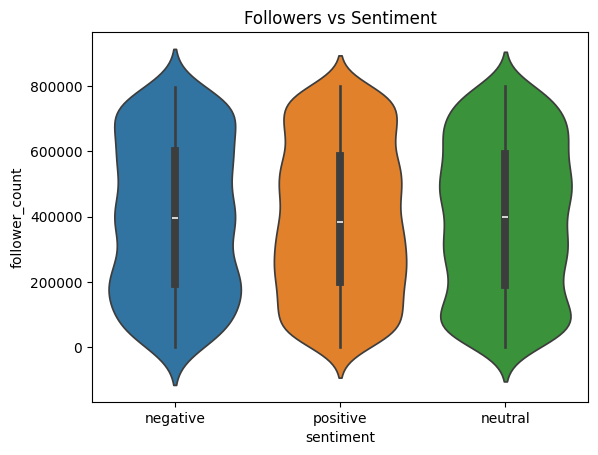

In [45]:
#Violin: followers vs sentiment

sns.violinplot(data=df,y="follower_count",x="sentiment",hue="sentiment")
plt.title("Followers vs Sentiment")
plt.show()

In [60]:
#Pair plot: numeric features

sns.pairplot(data=df,vars=numerical_col)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

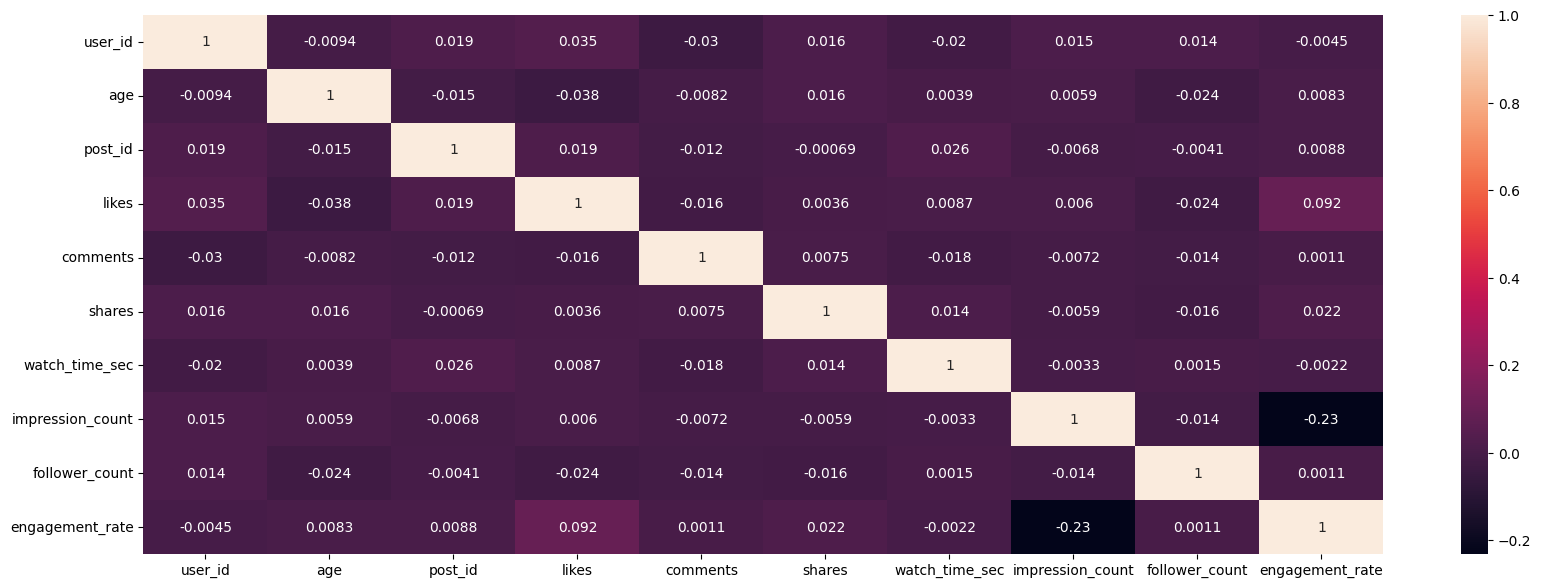

In [56]:
#Heatmap: correlation matrix

df_corr=df[numerical_col].corr()

plt.figure(figsize=(20,7))
sns.heatmap(df_corr,annot=True)
plt.show()

In [67]:
import warnings
warnings.filterwarnings("ignore")

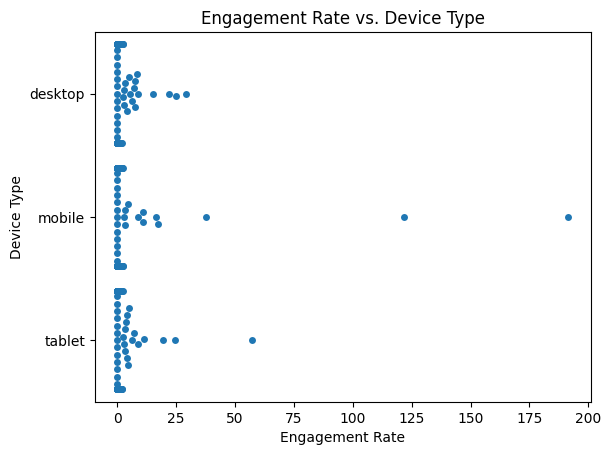

In [68]:
#Swarm plot: engagement vs device

# Sampling a smaller number of rows to make the swarm plot readable
df_sample = df.sample(n=1000, random_state=42)
sns.swarmplot(data=df_sample, x="engagement_rate", y="device_type")
plt.title("Engagement Rate vs. Device Type")
plt.xlabel("Engagement Rate")
plt.ylabel("Device Type")
plt.show()

Plotly (Interactive)
Interactive line chart/bar chart/bubble/scatter chart


In [87]:
#line chart
#Daily engagement trend

import plotly.express as px

fig=px.line(df,x="posted_at",y="engagement_rate",title="Daily engagement trend")
fig.show()

In [84]:
#bar chart
#avg likes by category

fig=px.bar(data_frame=df,x="post_category",y="likes",title="Avg likes by category",color="post_category")
fig.show()

In [91]:
# likes vs impressions

fig=px.scatter(df,x="likes",y="impression_count",title="likes vs impressions",color="gender")
fig.show()